In [ ]:
import numpy as np
import pandas as pd
df=pd.read_csv('/content/heart.csv')

In [ ]:
df.info()
df.head(4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0


In [ ]:

df[df.duplicated(keep=False)]
df.drop_duplicates(inplace=True)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Outlier Detection using Box Plots

Box plots are a great way to visualize the distribution of numerical data and identify potential outliers.

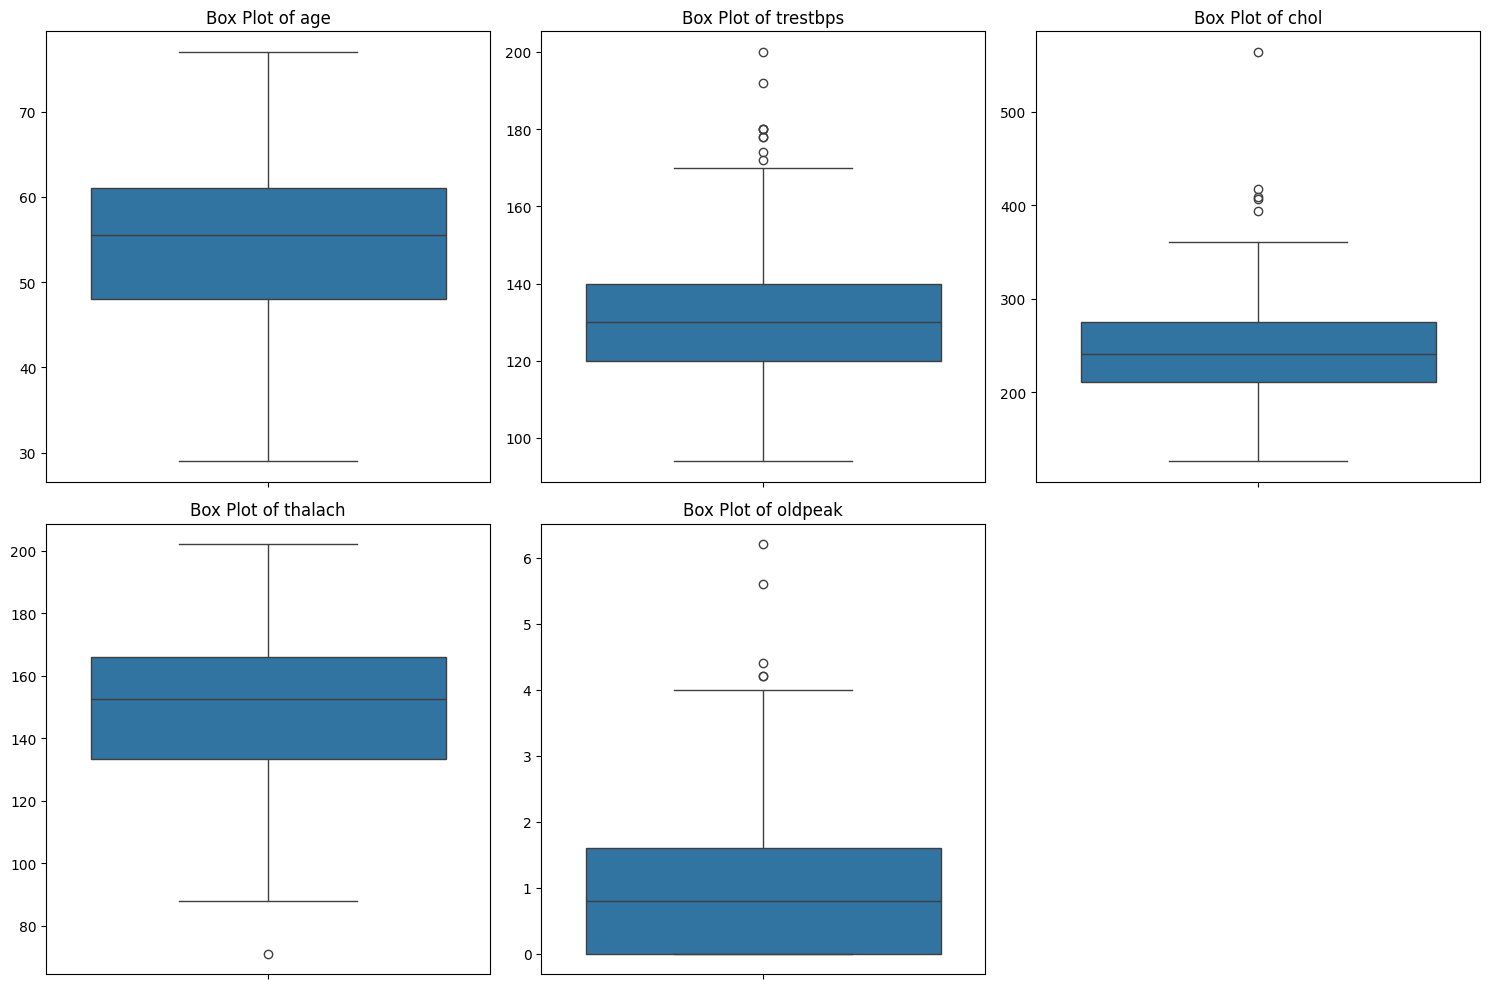

In [ ]:
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Arrange plots in 2 rows, 3 columns
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('') # Remove y-label as it's redundant
plt.tight_layout()
plt.show()

### Outlier Minimization (Capping)

We will cap the outliers at the 1st and 99th percentiles to minimize their impact.

In [ ]:
for col in ['trestbps', 'chol', 'oldpeak']:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("Outliers capped for 'trestbps', 'chol', and 'oldpeak'.")
display(df[['trestbps', 'chol', 'oldpeak']].describe())

Outliers capped for 'trestbps', 'chol', and 'oldpeak'.


,trestbps,chol,oldpeak
count,302.000000,302.000000,302.000000
mean,131.536424,246.100927,1.031126
std,17.135099,48.789893,1.119545
min,100.000000,149.000000,0.000000
25%,120.000000,211.000000,0.000000
50%,130.000000,240.500000,0.800000
75%,140.000000,274.750000,1.600000
max,180.000000,406.870000,4.200000


### Re-checking Outliers with Box Plots (after capping)

Let's visualize the box plots again to see the effect of capping.

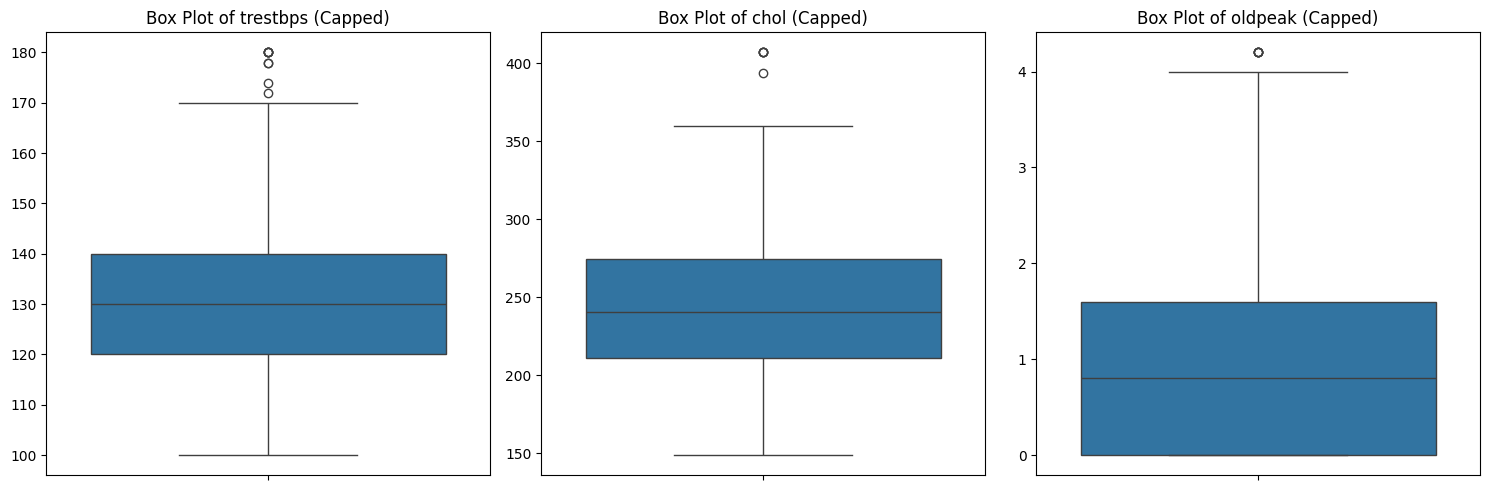

In [ ]:
numerical_cols_to_check = ['trestbps', 'chol', 'oldpeak']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols_to_check):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col} (Capped)')
    plt.ylabel('')
plt.tight_layout()
plt.show()

### Encoding Categorical Variables (One-Hot Encoding)

Many machine learning models perform better when categorical features are one-hot encoded, especially when there's no inherent ordinal relationship. This prevents the model from assuming a false numerical order.

In [ ]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Categorical columns one-hot encoded.")
display(df.head())

Categorical columns one-hot encoded.


,age,trestbps,chol,thalach,oldpeak,target,sex_1,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,52,125.0,212.0,168,1.0,0,True,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,53,140.0,203.0,155,3.1,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,70,145.0,174.0,125,2.6,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,61,148.0,203.0,161,0.0,0,True,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,62,138.0,294.0,106,1.9,0,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False


### Feature Scaling (Standardization)

Feature scaling is important to ensure that all features contribute equally to the model's performance. Standardization transforms features to have a mean of 0 and a standard deviation of 1, which is suitable for many machine learning algorithms.

In [ ]:
numerical_cols_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

scaler = StandardScaler()
df[numerical_cols_to_scale] = scaler.fit_transform(df[numerical_cols_to_scale])

print("Numerical columns standardized.")
display(df.head())

Numerical columns standardized.


,age,trestbps,chol,thalach,oldpeak,target,sex_1,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,-0.267966,-0.382097,-0.700094,0.806035,-0.027848,0,True,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,-0.157260,0.494752,-0.884865,0.237495,1.851028,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,1.724733,0.787035,-1.480237,-1.074521,1.403676,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,0.728383,0.962405,-0.884865,0.499898,-0.922551,0,True,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,0.839089,0.377839,0.983371,-1.905464,0.777384,0,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False


### Feature Selection

Feature selection is crucial for identifying the most relevant features that contribute to the prediction of the target variable. This helps in reducing model complexity, preventing overfitting, and potentially improving model performance and interpretability. We will use `SelectKBest` with the `f_classif` scoring function, which is suitable for numerical input variables and a categorical target variable.

In [ ]:
# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Apply SelectKBest to get the best features
from sklearn.feature_selection import SelectKBest, f_classif

# Select all features for now to get their scores
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

# Get the feature importance scores
feature_scores = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_})
feature_scores = feature_scores.sort_values(by='Score', ascending=False)

print("Feature importance scores:")
display(feature_scores.head(10))

Feature importance scores:


,Feature,Score
20,thal_2,114.769795
21,thal_3,92.215953
12,exang_1,70.255191
4,oldpeak,69.455597
3,thalach,64.237793
14,slope_2,54.508884
13,slope_1,44.742710
7,cp_2,32.743618
5,sex_1,26.240952
16,ca_2,24.215654


### Plotting Feature Importances

Now, let's visualize the importance of all features using a bar plot. This will clearly show which features have the highest scores and are therefore most impactful in predicting the target variable.

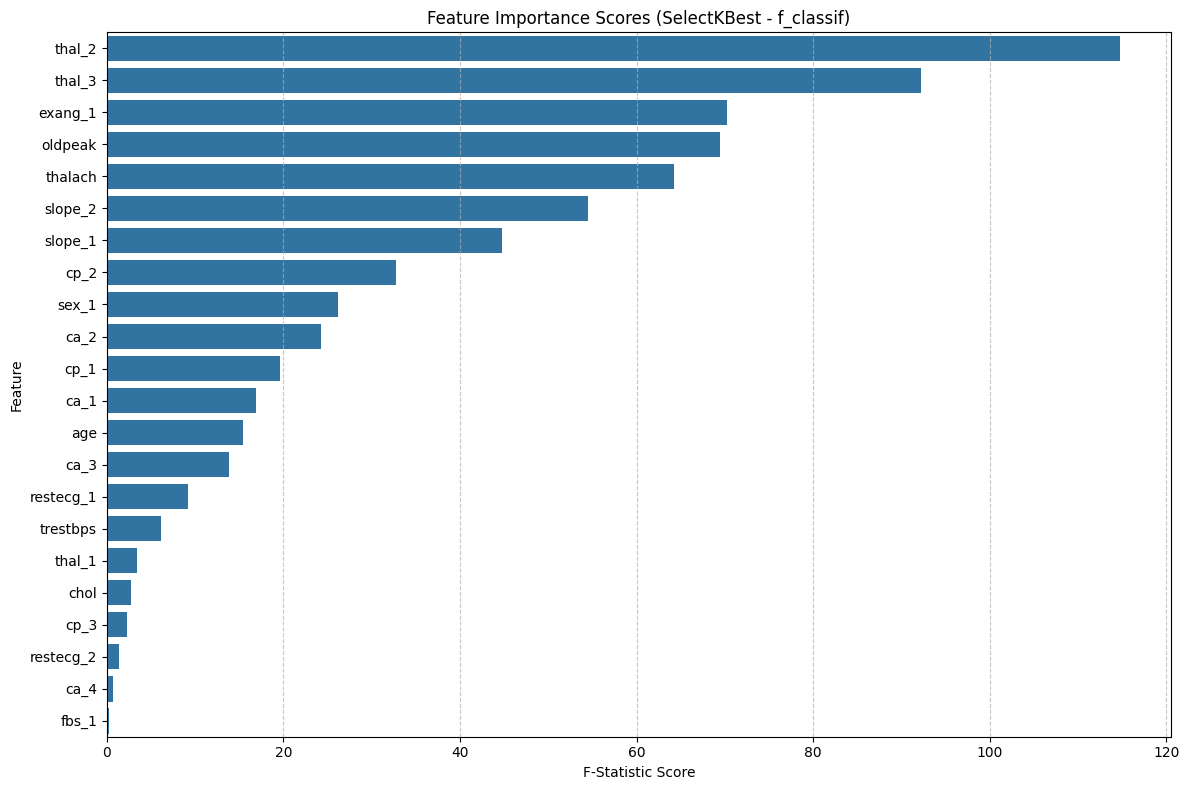

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Score', y='Feature', data=feature_scores)
plt.title('Feature Importance Scores (SelectKBest - f_classif)')
plt.xlabel('F-Statistic Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Selecting Top 10 Features

Based on the feature importance scores, we will now select the top 10 most impactful features to be used for model training. This step helps in reducing dimensionality, potentially improving model performance and reducing training time.

In [ ]:
top_10_features = feature_scores.head(10)['Feature'].tolist()
X_selected = X[top_10_features]

print(f"Selected Top 10 Features: {top_10_features}")
display(X_selected.head())

Selected Top 10 Features: ['thal_2', 'thal_3', 'exang_1', 'oldpeak', 'thalach', 'slope_2', 'slope_1', 'cp_2', 'sex_1', 'ca_2']


,thal_2,thal_3,exang_1,oldpeak,thalach,slope_2,slope_1,cp_2,sex_1,ca_2
0,False,True,False,-0.027848,0.806035,True,False,False,True,True
1,False,True,True,1.851028,0.237495,False,False,False,True,False
2,False,True,True,1.403676,-1.074521,False,False,False,True,False
3,False,True,False,-0.922551,0.499898,True,False,False,True,False
4,True,False,False,0.777384,-1.905464,False,True,False,False,False


### Histograms of Numerical Features

Let's visualize the distribution of each numerical feature after scaling.

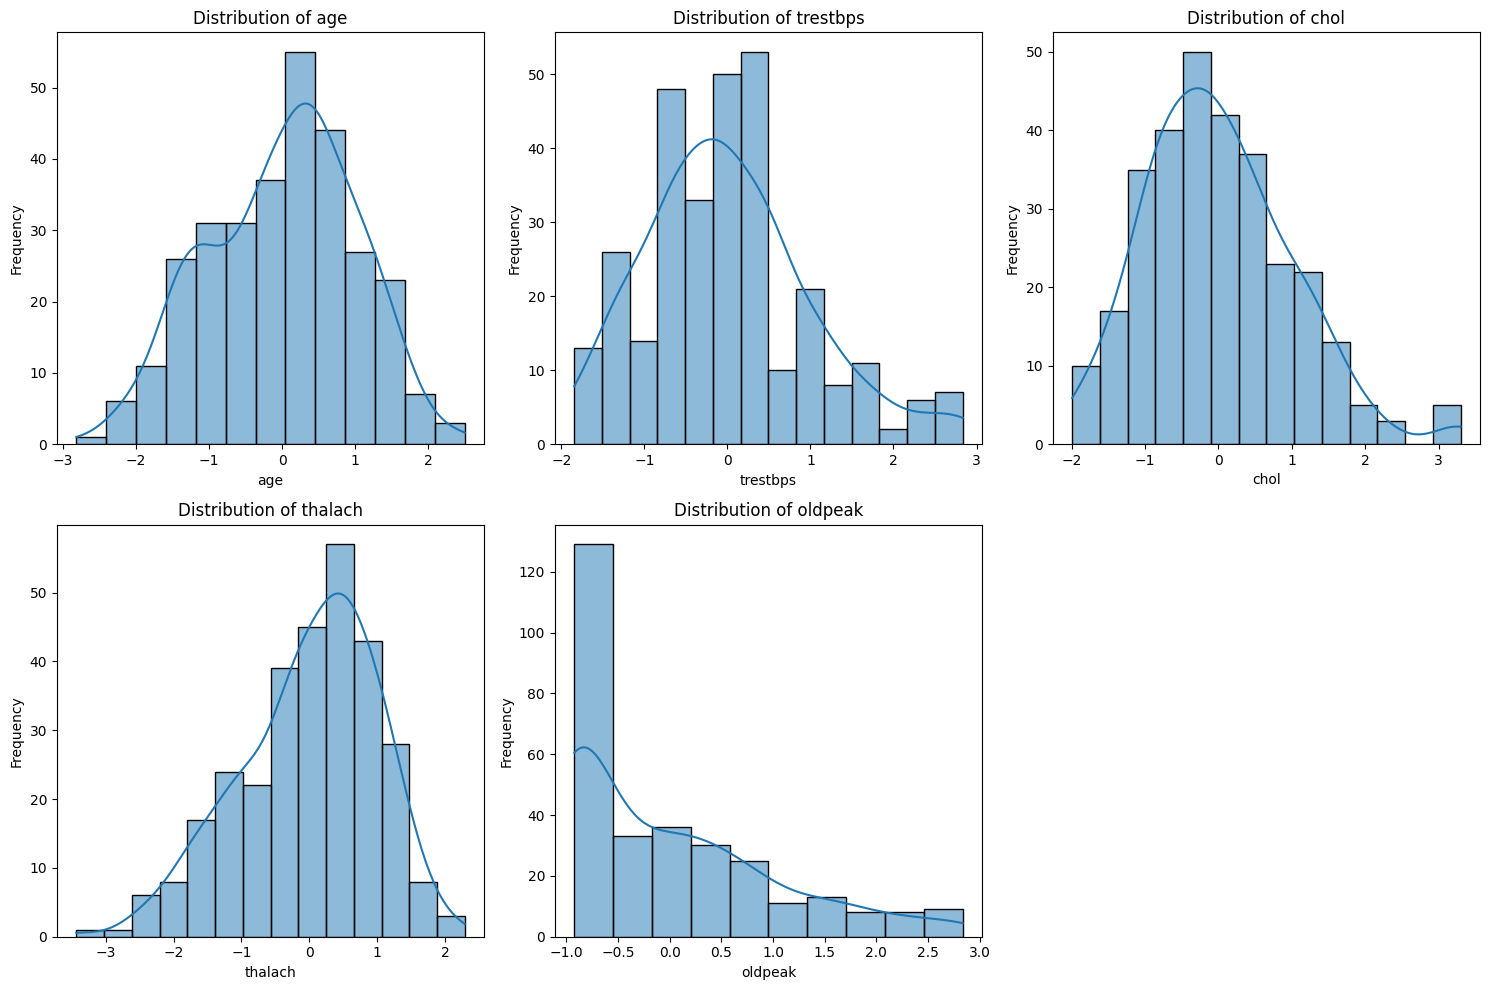

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_to_scale):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Correlation Analysis (Heatmap)

Now, let's visualize the correlation matrix of all features (including the one-hot encoded ones) and the target variable. This will help us understand the linear relationships between variables.

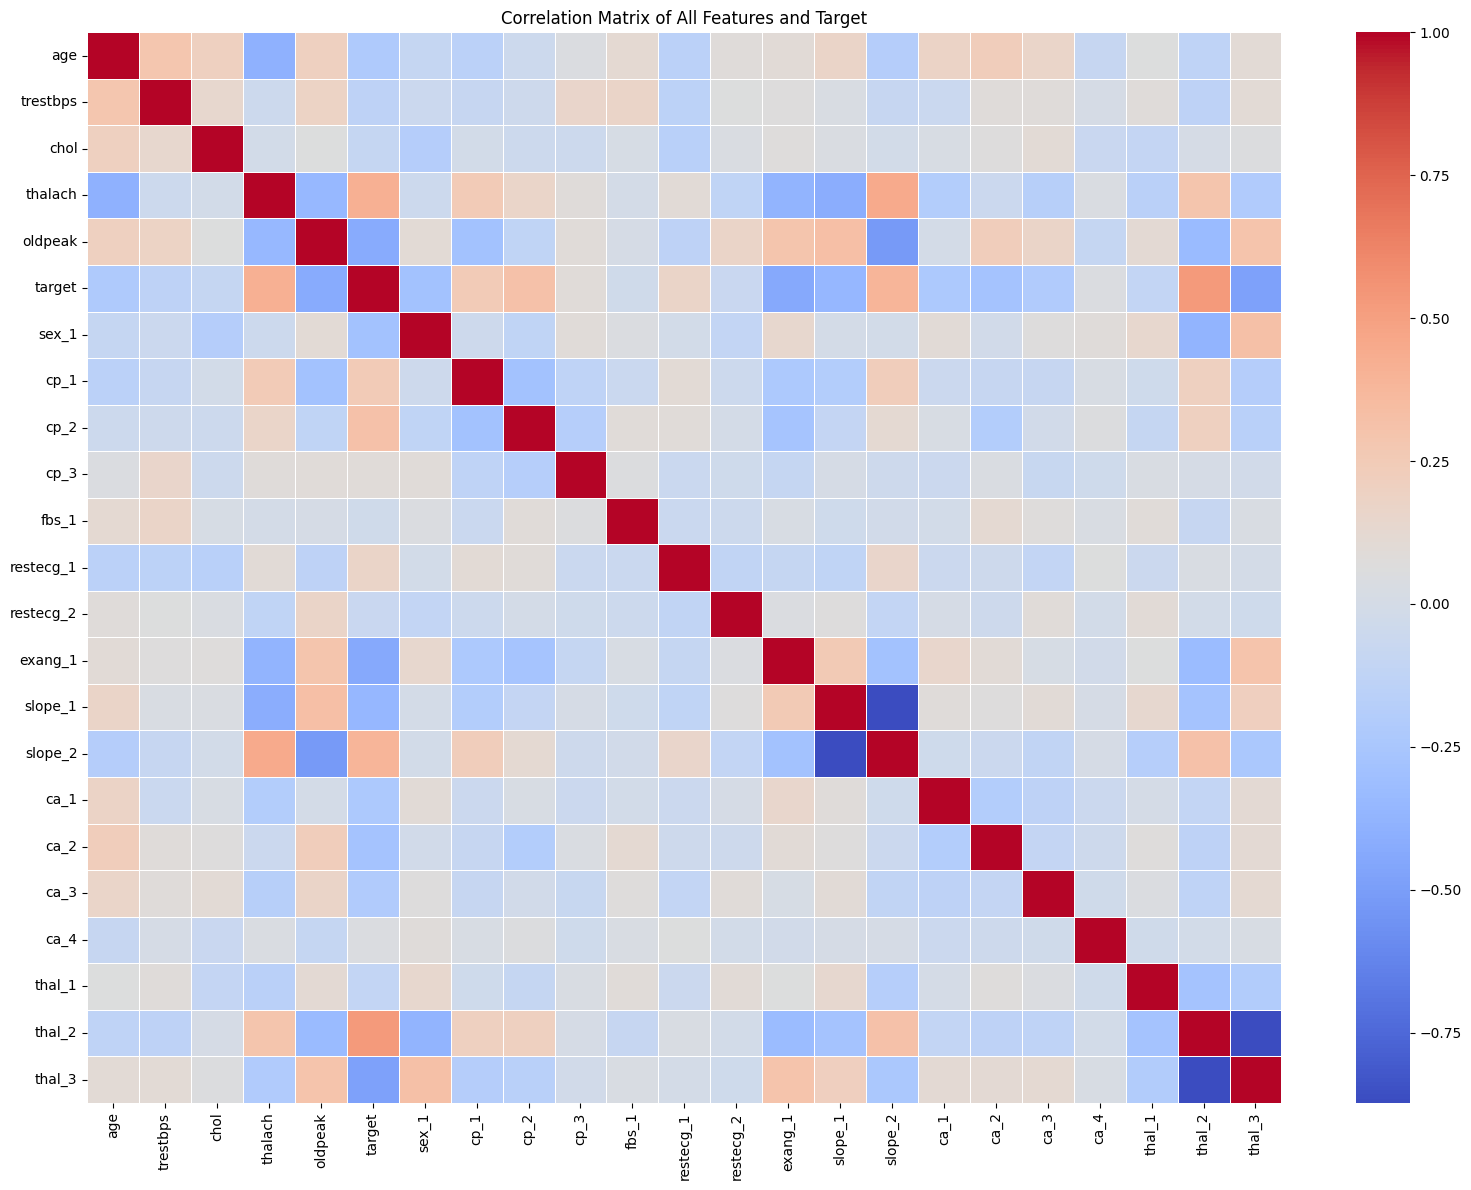

In [ ]:
plt.figure(figsize=(16, 12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Features and Target')
plt.tight_layout()
plt.show()

### Target vs. Numerical Features Plots

These box plots show the distribution of each numerical feature for both classes of the target variable (0 and 1), helping to identify features that differentiate between them.

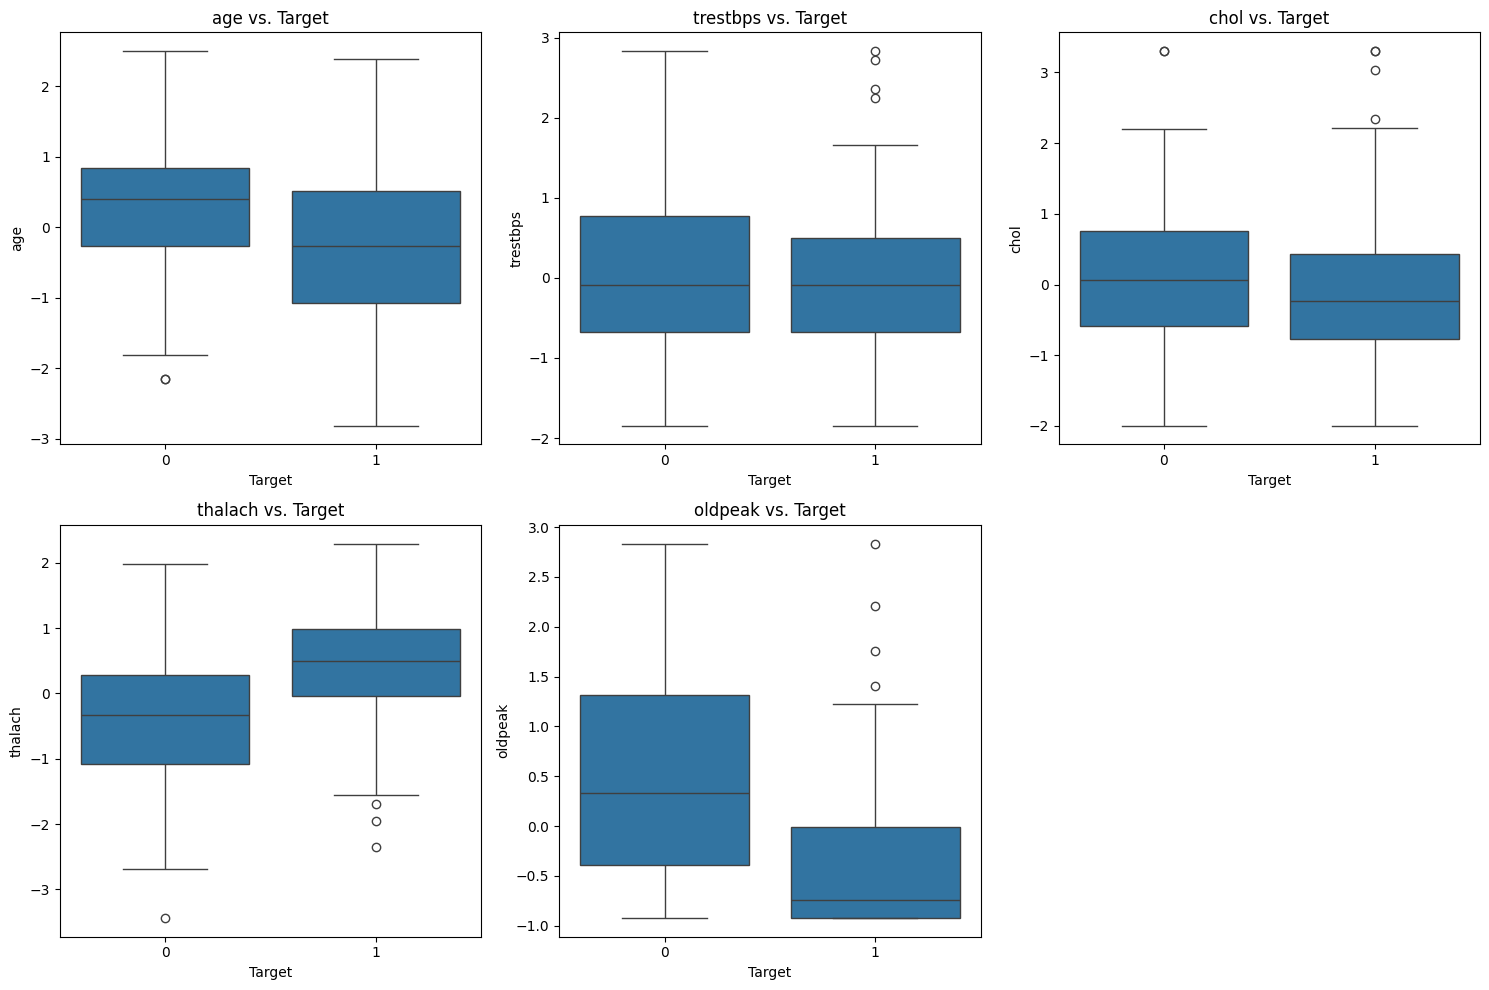

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_to_scale):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='target', y=col, data=df)
    plt.title(f'{col} vs. Target')
    plt.xlabel('Target')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Target vs. Original Categorical Features Plots

Let's visualize the distribution of each original categorical feature against the target variable to see how different categories relate to the target outcome. (Note: These plots use the *original* categorical columns, not the one-hot encoded ones, for better interpretability.)

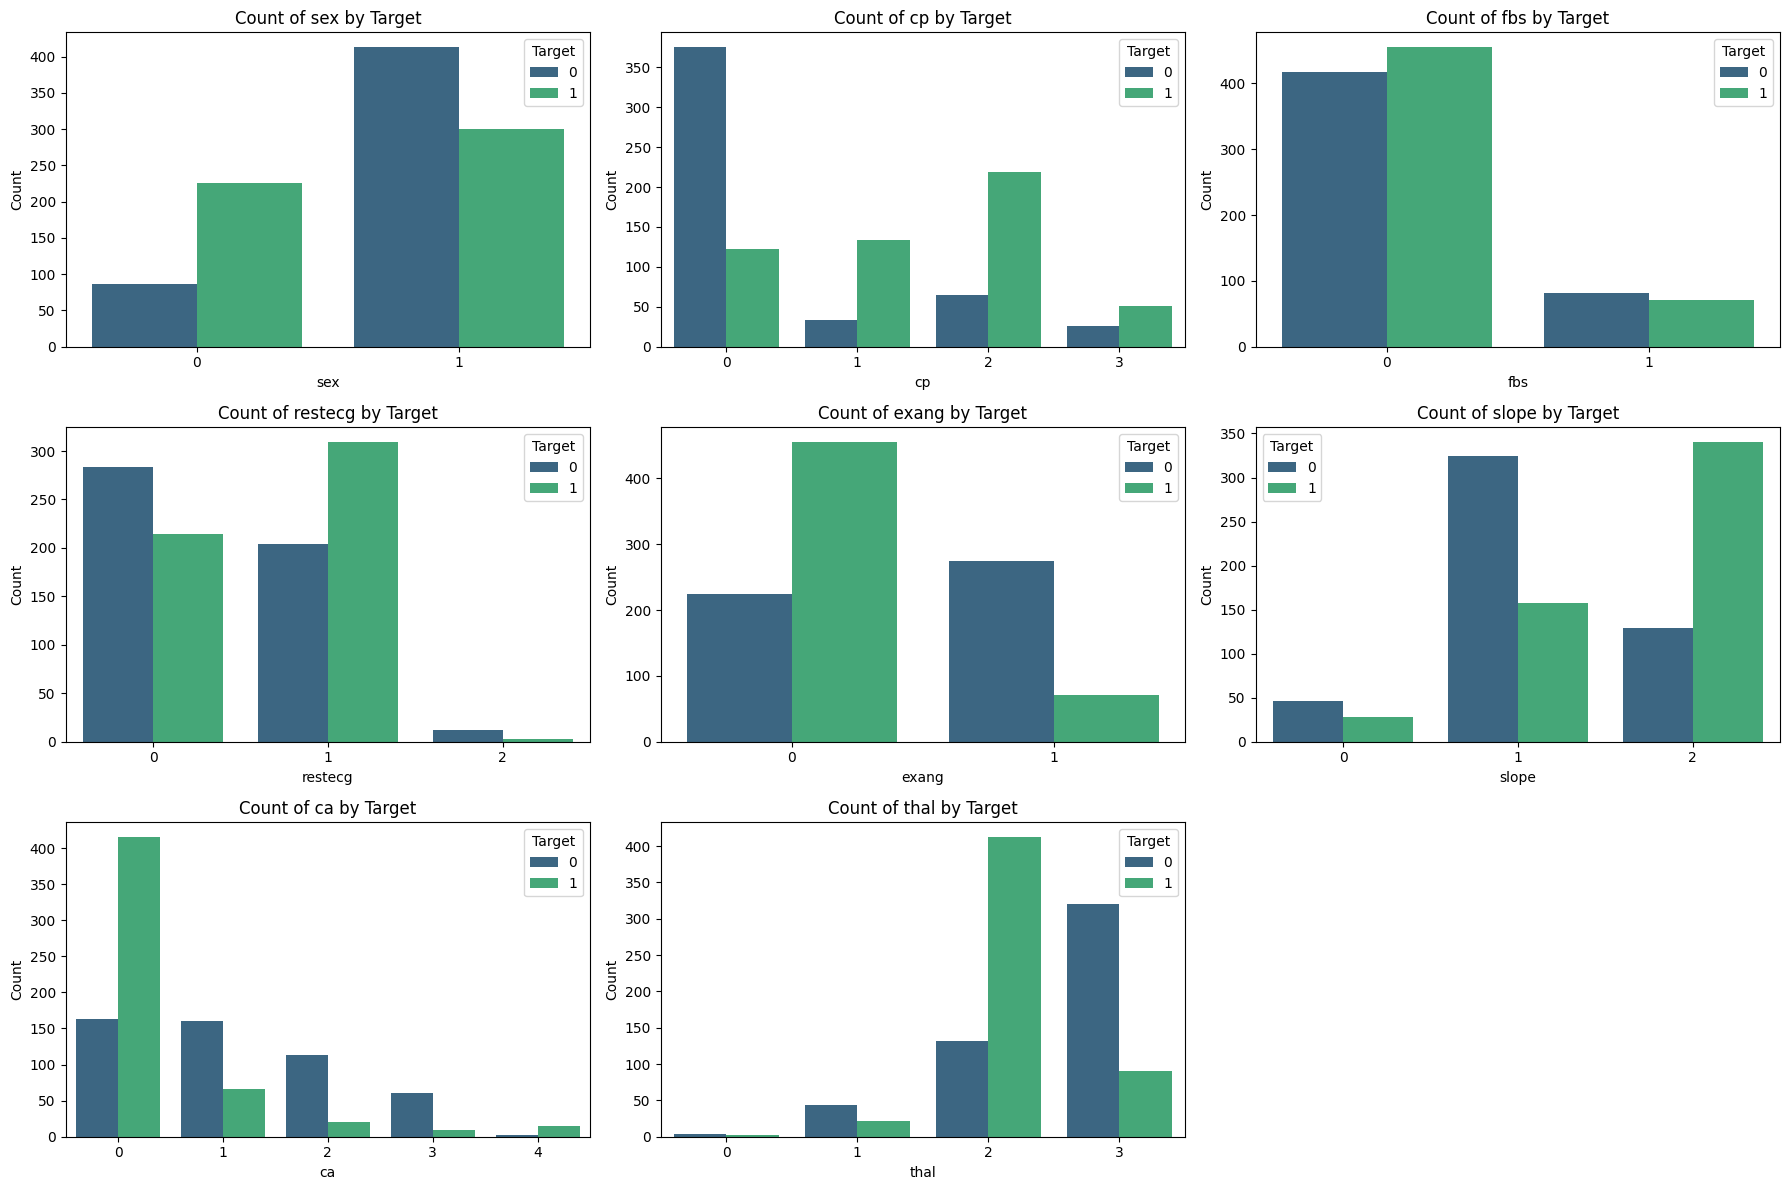

Note: The above plots for categorical features use a fresh read of the original data to show the relationship with the target before one-hot encoding. For features already one-hot encoded and present in the main 'df', you can analyze their correlation directly from the heatmap.


In [ ]:
# To plot original categorical features, we need the df before one-hot encoding for this visualization purpose.
# Let's reload the df briefly for plotting original categorical vs target or use the original df if it was saved.
# For now, let's assume `df_original` (before encoding) is available or re-create it for plotting.
# If `df_original` is not available, you would need to recreate it from `heart.csv` before encoding and scaling.
# For demonstration, assuming a temporary df_temp for plotting original categorical relationships.

# NOTE: If you ran the entire notebook, 'df' has been transformed.
# To get the original categorical values for plotting, we need to load a fresh copy or use the `categorical_cols` list
# to get the non-encoded representation if that was stored.

# For this demonstration, we'll assume we need to re-read the CSV to get original categorical values for clear plotting.
# In a real scenario, you might save an intermediate DataFrame.

df_plotting_categorical = pd.read_csv('/content/heart.csv')

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.countplot(x=col, hue='target', data=df_plotting_categorical, palette='viridis')
    plt.title(f'Count of {col} by Target')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Target')
plt.tight_layout()
plt.show()

print("Note: The above plots for categorical features use a fresh read of the original data to show the relationship with the target before one-hot encoding. For features already one-hot encoded and present in the main 'df', you can analyze their correlation directly from the heatmap.")

### Splitting Data into Training and Testing Sets

To prepare for model training and evaluation, we'll split our features (`X_selected`) and target variable (`y`) into training and testing sets. This ensures that we can assess the model's performance on unseen data, providing a more reliable measure of its generalization capabilities.

In [ ]:
# Split the data using the selected top 10 features
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("Data split into training and testing sets.")

X_train shape: (241, 10)
X_test shape: (61, 10)
y_train shape: (241,)
y_test shape: (61,)
Data split into training and testing sets.


### Model Training: Logistic Regression

We will start with a Logistic Regression model, a widely used and interpretable algorithm for binary classification tasks. It models the probability that a given input belongs to a particular class.

In [ ]:
# Initialize and train the Logistic Regression model
logistic_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and allows for L1/L2 regularization
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Model Evaluation: Logistic Regression

Now, let's evaluate the performance of our trained Logistic Regression model on the test set. We'll look at key metrics like accuracy, precision, recall, F1-score, and the confusion matrix to understand how well the model is performing.

Logistic Regression Accuracy: 0.8361

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83        28
           1       0.90      0.79      0.84        33

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



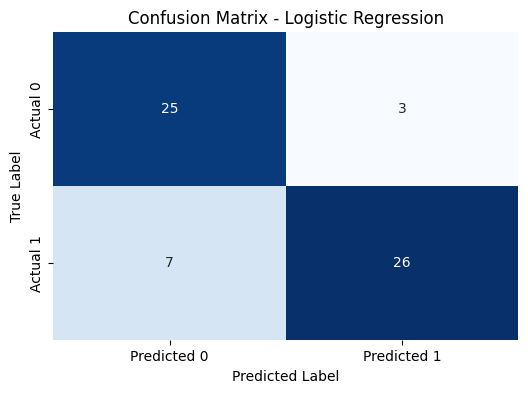

In [ ]:
# Make predictions on the test set
y_pred_lr = logistic_model.predict(X_test)

# Calculate accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Display confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### Storing Results for Comparison

To facilitate comparison between different models, we will store the accuracy and other relevant metrics in a dictionary.

In [ ]:
model_performance = {}
model_performance['Logistic Regression'] = {'Accuracy': accuracy_lr, 'Classification Report': classification_report(y_test, y_pred_lr, output_dict=True), 'Confusion Matrix': cm_lr.tolist()}

print("Logistic Regression performance metrics stored.")

Logistic Regression performance metrics stored.


**Reasoning**:
To train a Decision Tree Classifier, I need to import the necessary class, initialize the model with the specified `random_state`, and then fit it to the training data. This fulfills the instructions for the subtask.



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree Classifier model trained successfully.")

Decision Tree Classifier model trained successfully.


**Reasoning**:
Now that the Decision Tree Classifier model has been trained, the next step is to evaluate its performance on the test set. This involves making predictions, calculating accuracy, and generating a classification report and confusion matrix, similar to the evaluation process for the Logistic Regression model.



Decision Tree Classifier Accuracy: 0.8361

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        28
           1       0.85      0.85      0.85        33

    accuracy                           0.84        61
   macro avg       0.83      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



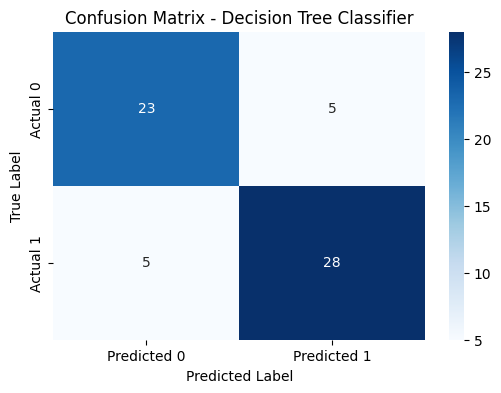

In [ ]:
# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Calculate accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Classifier Accuracy: {accuracy_dt:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Display confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Reasoning**:
The next step is to store the evaluation metrics of the Decision Tree Classifier model, including accuracy, classification report, and confusion matrix, into the `model_performance` dictionary for later comparison.



In [ ]:
model_performance['Decision Tree Classifier'] = {'Accuracy': accuracy_dt, 'Classification Report': classification_report(y_test, y_pred_dt, output_dict=True), 'Confusion Matrix': cm_dt.tolist()}

print("Decision Tree Classifier performance metrics stored.")

Decision Tree Classifier performance metrics stored.


**Reasoning**:
To summarize the performance of all evaluated models, I will convert the `model_performance` dictionary into a pandas DataFrame and display it.



In [ ]:
print("\n--- Model Performance Summary ---")
performance_df = pd.DataFrame(model_performance).T # Transpose for better readability

# Extract scalar metrics directly for comparison
summary_data = {}
for model, metrics in model_performance.items():
    summary_data[model] = {
        'Accuracy': metrics['Accuracy'],
        'Precision_0': metrics['Classification Report']['0']['precision'],
        'Recall_0': metrics['Classification Report']['0']['recall'],
        'F1_Score_0': metrics['Classification Report']['0']['f1-score'],
        'Precision_1': metrics['Classification Report']['1']['precision'],
        'Recall_1': metrics['Classification Report']['1']['recall'],
        'F1_Score_1': metrics['Classification Report']['1']['f1-score']
    }

summary_df = pd.DataFrame(summary_data).T
print("Summary of Accuracy, Precision, Recall, and F1-Score for each model:")
display(summary_df)


--- Model Performance Summary ---
Summary of Accuracy, Precision, Recall, and F1-Score for each model:


,Accuracy,Precision_0,Recall_0,F1_Score_0,Precision_1,Recall_1,F1_Score_1
Logistic Regression,0.836066,0.781250,0.892857,0.833333,0.896552,0.787879,0.838710
Decision Tree Classifier,0.836066,0.821429,0.821429,0.821429,0.848485,0.848485,0.848485


# Task
Train and evaluate a Decision Tree Classifier model on the prepared data, store its performance metrics in `model_performance`, and then summarize the performance of all evaluated models for comparison.

## Train Decision Tree Model

### Subtask:
Train a Decision Tree Classifier model using the training data (X_train, y_train).


## Summary:

### Q&A
The task implicitly asked for a comparison of the Decision Tree Classifier's performance against other models. The Decision Tree Classifier's performance was compared to that of a Logistic Regression model.

### Data Analysis Key Findings
*   A Decision Tree Classifier model was successfully trained on the provided data.
*   The Decision Tree Classifier achieved an accuracy of approximately 0.8361 on the test set.
*   When compared to a previously evaluated Logistic Regression model, both models demonstrated a very similar overall accuracy of approximately 0.836.
*   Detailed performance metrics including precision, recall, and F1-score for both classes (0 and 1) were computed and summarized for both the Decision Tree Classifier and Logistic Regression, enabling a granular comparison of their performance.

### Insights or Next Steps
*   Since both Logistic Regression and Decision Tree Classifier show very similar overall accuracy, a detailed analysis of their precision, recall, and F1-scores for each class is crucial to identify which model is more suitable based on the specific business problem (e.g., minimizing false positives vs. false negatives).
*   Hyperparameter tuning for both models should be considered to potentially improve their performance and explore if one model can significantly outperform the other with optimal settings.


# Task
Train an SVM model using `X_train` and `y_train`.

## Train SVM Model

### Subtask:
Train a Support Vector Machine (SVM) model using the training data (X_train, y_train).


**Reasoning**:
To train an SVM model, I need to import the `SVC` class, initialize it with a `random_state` for reproducibility, and then fit it to the training data. This directly addresses the instructions for training the SVM model.



In [ ]:
from sklearn.svm import SVC

# Initialize the Support Vector Machine model
svm_model = SVC(random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

print("Support Vector Machine model trained successfully.")

Support Vector Machine model trained successfully.


**Reasoning**:
Now that the SVM model has been trained, the next step is to evaluate its performance on the test set. This involves making predictions, calculating accuracy, and generating a classification report and confusion matrix, similar to the evaluation process for previous models.



Support Vector Machine Accuracy: 0.8033

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.89      0.81        28
           1       0.89      0.73      0.80        33

    accuracy                           0.80        61
   macro avg       0.81      0.81      0.80        61
weighted avg       0.82      0.80      0.80        61



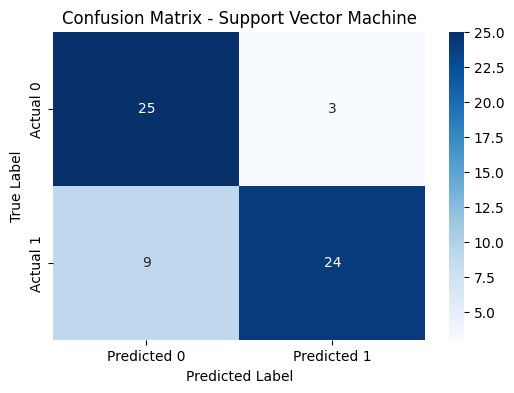

In [ ]:
# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

# Calculate accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Support Vector Machine Accuracy: {accuracy_svm:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# Display confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Support Vector Machine')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Reasoning**:
The next step is to store the evaluation metrics of the SVM model, including accuracy, classification report, and confusion matrix, into the `model_performance` dictionary for later comparison.



In [ ]:
model_performance['Support Vector Machine'] = {'Accuracy': accuracy_svm, 'Classification Report': classification_report(y_test, y_pred_svm, output_dict=True), 'Confusion Matrix': cm_svm.tolist()}

print("Support Vector Machine performance metrics stored.")

Support Vector Machine performance metrics stored.


# Task
Prepare the accuracy data for each model from the `model_performance` dictionary, specifically extracting the model names and their accuracy scores into a pandas DataFrame.

## Prepare Accuracy Data

### Subtask:
Extract the accuracy scores for each model from the `model_performance` dictionary and prepare them for plotting. This will involve creating a DataFrame with model names and their corresponding accuracies.


**Reasoning**:
To prepare the accuracy data for plotting, I will iterate through the `model_performance` dictionary, extract each model's accuracy, and store it in a list of dictionaries. This list will then be converted into a pandas DataFrame named `accuracy_df` as specified in the instructions.



In [ ]:
accuracy_data = []

for model_name, metrics in model_performance.items():
    accuracy = metrics['Accuracy']
    accuracy_data.append({'Model': model_name, 'Accuracy': accuracy})

accuracy_df = pd.DataFrame(accuracy_data)
print("Accuracy data prepared for plotting:")
display(accuracy_df)

Accuracy data prepared for plotting:


,Model,Accuracy
0,Logistic Regression,0.836066
1,Decision Tree Classifier,0.836066
2,Support Vector Machine,0.803279


**Reasoning**:
To visualize the accuracy of each model as requested, I will create a bar plot using seaborn, setting the model names on the x-axis and accuracy scores on the y-axis, and then customize the plot with titles, labels, y-axis limits, and text annotations for clarity.



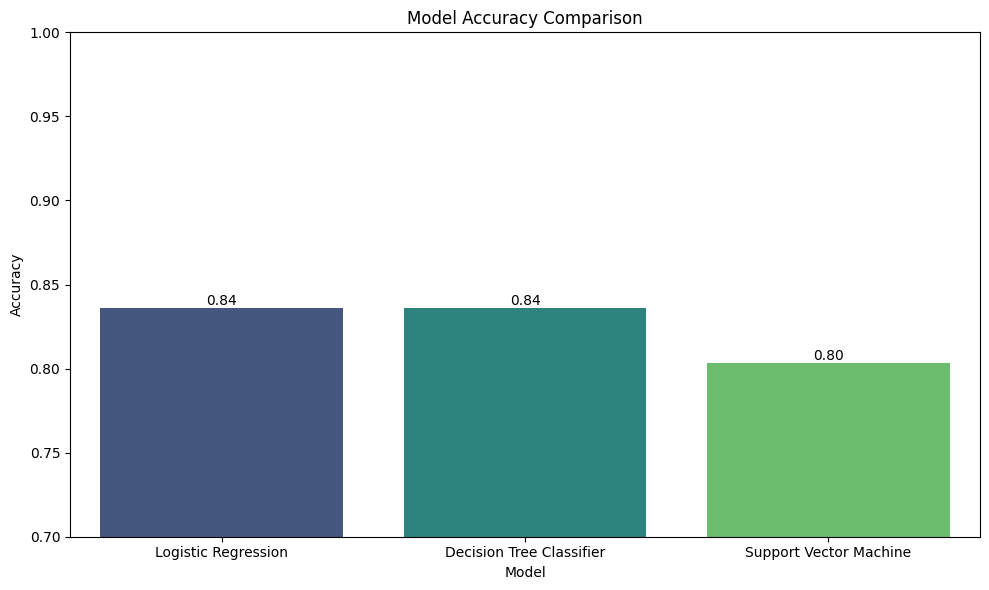

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis', hue='Model', legend=False)
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0) # Set appropriate y-axis limits

# Add accuracy values on top of the bars
for index, row in accuracy_df.iterrows():
    plt.text(index, row['Accuracy'], f"{row['Accuracy']:.2f}", color='black', ha="center", va='bottom')

plt.tight_layout()
plt.show()

## Plot Model Accuracies

### Subtask:
Generate a bar plot using seaborn to visualize the accuracy of each model. The plot should clearly display the model names on one axis and their accuracy scores on the other. Include a title, axis labels, and ensure the plot is legible.


## Final Task

### Subtask:
Display the plot comparing the accuracies of the trained models and provide any relevant insights.


## Summary:

### Q&A
The accuracies of the trained models were compared through a bar plot.

### Data Analysis Key Findings
*   A pandas DataFrame `accuracy_df` was successfully created, listing each model and its corresponding accuracy score.
*   The Logistic Regression model achieved an accuracy of approximately 0.836.
*   The Decision Tree Classifier also showed an accuracy of approximately 0.836, matching the Logistic Regression model.
*   The Support Vector Machine (SVM) model recorded a slightly lower accuracy of approximately 0.803.
*   A bar plot titled 'Model Accuracy Comparison' was generated, visually representing these accuracies, with accuracy values displayed on top of each bar.

### Insights or Next Steps
*   Both Logistic Regression and Decision Tree Classifier performed comparably and achieved the highest accuracy among the evaluated models, suggesting they are good candidates for further analysis.
*   Consider investigating the Support Vector Machine further, potentially through hyperparameter tuning or alternative kernel functions, to see if its performance can be improved to match the other top-performing models.


# Task
Perform hyperparameter tuning for the Logistic Regression model using GridSearchCV to find the best hyperparameters, then train and evaluate a new Logistic Regression model with these tuned hyperparameters, storing and visualizing its performance compared to other models.

## Hyperparameter Tuning for Logistic Regression

### Subtask:
Define a parameter grid for Logistic Regression and use GridSearchCV to find the best hyperparameters. This will involve importing GridSearchCV and setting up the parameter ranges for the 'solver' and 'C' parameters.


**Reasoning**:
To perform hyperparameter tuning for Logistic Regression, I will import `GridSearchCV`, define a parameter grid for `solver` and `C`, instantiate `GridSearchCV` with the Logistic Regression model, and then fit it to the training data. Finally, I will print the best parameters and score found by GridSearchCV.



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid for Logistic Regression
param_grid = {
    'solver': ['liblinear', 'saga'], # 'liblinear' is good for small datasets, 'saga' for larger ones and supports more regularization types
    'C': [0.001, 0.01, 0.1, 1, 10, 100] # Inverse of regularization strength
}

# Instantiate GridSearchCV
grid_search_lr = GridSearchCV(estimator=LogisticRegression(random_state=42), # Use LogisticRegression from previous imports
                              param_grid=param_grid,
                              cv=5, # 5-fold cross-validation
                              scoring='accuracy', # Evaluate based on accuracy
                              n_jobs=-1, # Use all available cores
                              verbose=1) # Display progress

# Fit GridSearchCV to the training data
grid_search_lr.fit(X_train, y_train)

print("GridSearchCV for Logistic Regression completed.")
print(f"Best parameters: {grid_search_lr.best_params_}")
print(f"Best cross-validation accuracy: {grid_search_lr.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
GridSearchCV for Logistic Regression completed.
Best parameters: {'C': 1, 'solver': 'liblinear'}
Best cross-validation accuracy: 0.7966


**Reasoning**:
Now that the best hyperparameters for Logistic Regression have been identified, the next step is to train a new Logistic Regression model using these optimal parameters and evaluate its performance on the test set. This directly addresses the main task's requirement to train and evaluate a model with tuned hyperparameters.



Tuned Logistic Regression model trained successfully.
Tuned Logistic Regression Accuracy: 0.8361

Classification Report (Tuned Logistic Regression):
              precision    recall  f1-score   support

           0       0.78      0.89      0.83        28
           1       0.90      0.79      0.84        33

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



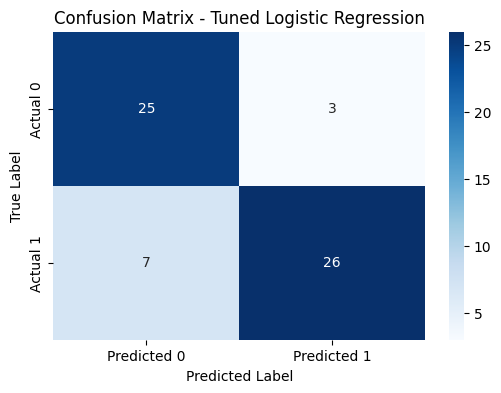

In [ ]:
# Get the best parameters from GridSearchCV
best_params_lr = grid_search_lr.best_params_

# Initialize and train a new Logistic Regression model with the best parameters
logistic_model_tuned = LogisticRegression(random_state=42, **best_params_lr)
logistic_model_tuned.fit(X_train, y_train)

print("Tuned Logistic Regression model trained successfully.")

# Make predictions on the test set
y_pred_lr_tuned = logistic_model_tuned.predict(X_test)

# Calculate accuracy
accuracy_lr_tuned = accuracy_score(y_test, y_pred_lr_tuned)
print(f"Tuned Logistic Regression Accuracy: {accuracy_lr_tuned:.4f}")

# Display classification report
print("\nClassification Report (Tuned Logistic Regression):")
print(classification_report(y_test, y_pred_lr_tuned))

# Display confusion matrix
cm_lr_tuned = confusion_matrix(y_test, y_pred_lr_tuned)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Reasoning**:
The current subtask involves evaluating the tuned Logistic Regression model and storing its performance metrics. This step will add the accuracy, classification report, and confusion matrix of the tuned model to the `model_performance` dictionary, making it available for comparison with other models.



In [ ]:
model_performance['Logistic Regression (Tuned)'] = {'Accuracy': accuracy_lr_tuned, 'Classification Report': classification_report(y_test, y_pred_lr_tuned, output_dict=True), 'Confusion Matrix': cm_lr_tuned.tolist()}

print("Tuned Logistic Regression performance metrics stored.")

Tuned Logistic Regression performance metrics stored.


**Reasoning**:
The `model_performance` dictionary has been updated with the tuned Logistic Regression model's metrics. To visually compare its performance with other models, the `accuracy_df` needs to be regenerated to include the new model.



In [ ]:
accuracy_data = []

for model_name, metrics in model_performance.items():
    accuracy = metrics['Accuracy']
    accuracy_data.append({'Model': model_name, 'Accuracy': accuracy})

accuracy_df = pd.DataFrame(accuracy_data)
print("Accuracy data prepared for plotting, including tuned Logistic Regression:")
display(accuracy_df)

Accuracy data prepared for plotting, including tuned Logistic Regression:


,Model,Accuracy
0,Logistic Regression,0.836066
1,Decision Tree Classifier,0.836066
2,Support Vector Machine,0.803279
3,Logistic Regression (Tuned),0.836066


**Reasoning**:
The `accuracy_df` is now updated with the tuned Logistic Regression model's performance. The final part of the subtask is to visualize the performance comparison of all models, including the tuned Logistic Regression, using a bar plot.



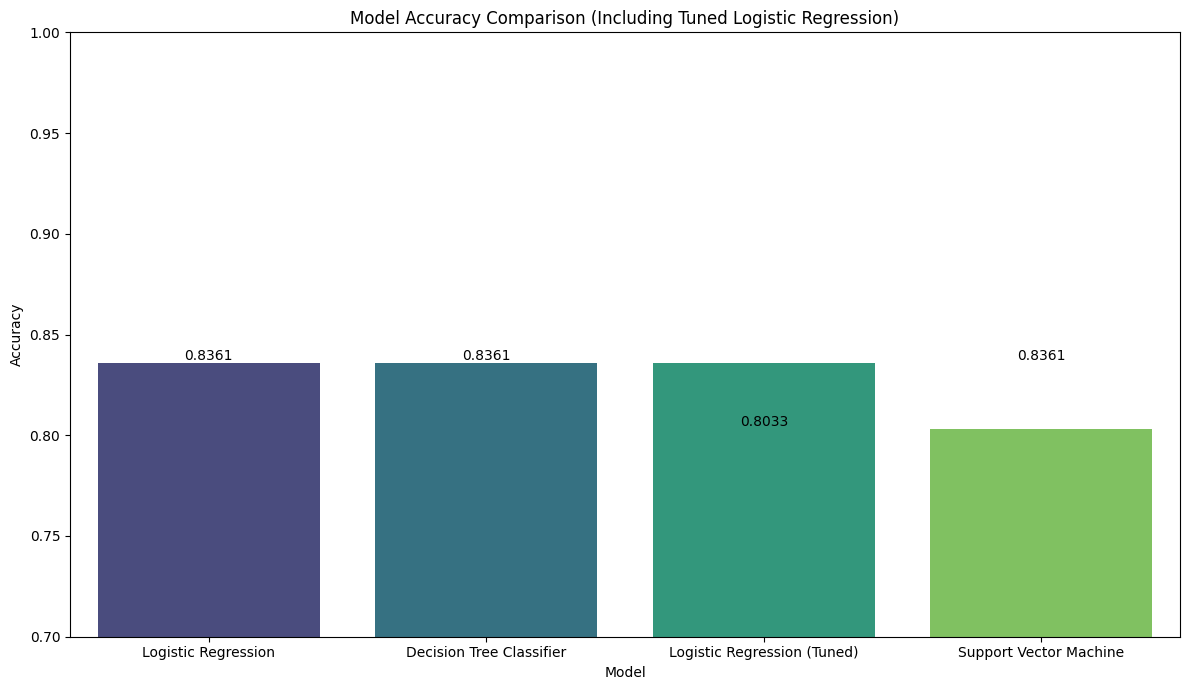

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df.sort_values(by='Accuracy', ascending=False), palette='viridis', hue='Model', legend=False)
plt.title('Model Accuracy Comparison (Including Tuned Logistic Regression)')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0) # Set appropriate y-axis limits to highlight differences

# Add accuracy values on top of the bars
for index, row in accuracy_df.iterrows():
    plt.text(index, row['Accuracy'], f"{row['Accuracy']:.4f}", color='black', ha="center", va='bottom')

plt.tight_layout()
plt.show()

### Train and Evaluate Tuned Logistic Regression Model

Now that we have identified the best hyperparameters for the Logistic Regression model using `GridSearchCV`, we will train a new Logistic Regression model with these parameters. Subsequently, we will evaluate its performance on the test set (`X_test`, `y_test`) and store its metrics for comparison with other models.

## Final Task

### Subtask:
Summarize the findings from the hyperparameter tuning and model comparison, highlighting any improvements in accuracy.


## Summary:

### Q&A
The hyperparameter tuning for the Logistic Regression model did not result in an improvement in accuracy on the test set when compared to the untuned Logistic Regression model. The tuned model achieved an accuracy of 0.8361, which is identical to the untuned Logistic Regression and Decision Tree Classifier models.

### Data Analysis Key Findings
*   Hyperparameter tuning for Logistic Regression using `GridSearchCV` identified the best parameters as `{'C': 1, 'solver': 'liblinear'}`.
*   The best cross-validation accuracy achieved during the tuning process was 0.7966.
*   The Logistic Regression model, after being tuned with the optimal hyperparameters, achieved a test set accuracy of 0.8361.
*   This tuned Logistic Regression model's test accuracy of 0.836066 was found to be identical to both the untuned Logistic Regression model and the Decision Tree Classifier.
*   The performance metrics of the tuned Logistic Regression model were successfully stored and visually compared against other models, showing its relative standing.

### Insights or Next Steps
*   Since hyperparameter tuning for Logistic Regression did not yield an improvement in accuracy over the untuned version or other models like Decision Tree, further investigation into more complex models or alternative feature engineering techniques might be beneficial to enhance predictive performance.
*   Consider exploring other advanced regularization techniques or ensemble methods if higher accuracy is required, as the current Logistic Regression models (tuned and untuned) appear to have reached a performance plateau.


# Task
Generate histograms and descriptive statistics for all numerical features to understand their distribution, central tendency, and spread. Provide legends for the plots.

**Reasoning**:
To prompt the user for input and store it in a dictionary, I need to create a code block that initializes an empty dictionary, defines the features, iterates through them, prompts for input with appropriate type casting, and stores the values.



In [ ]:
manual_input_data = {}
features_to_collect = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

print("Please enter values for the following patient features:")
for feature in features_to_collect:
    while True:
        try:
            if feature == 'oldpeak':
                value = float(input(f"Enter value for {feature}: "))
            else:
                value = int(input(f"Enter value for {feature}: "))
            manual_input_data[feature] = value
            break
        except ValueError:
            print(f"Invalid input for {feature}. Please enter a valid {'decimal number' if feature == 'oldpeak' else 'integer'}.")

print("Manual input data collected:")
print(manual_input_data)

Please enter values for the following patient features:
Enter value for age: 20
Enter value for sex: 1
Enter value for cp: 3
Enter value for trestbps: 40
Enter value for chol: 5
Enter value for fbs: 66
Enter value for restecg: 45
Enter value for thalach: 74
Enter value for exang: 12
Enter value for oldpeak: 22
Enter value for slope: 32
Enter value for ca: 546
Enter value for thal: 641
Manual input data collected:
{'age': 20, 'sex': 1, 'cp': 3, 'trestbps': 40, 'chol': 5, 'fbs': 66, 'restecg': 45, 'thalach': 74, 'exang': 12, 'oldpeak': 22.0, 'slope': 32, 'ca': 546, 'thal': 641}


# Task
The user wants to get predictions for a manually entered patient data. I need to create a function that takes raw patient data, preprocesses it exactly as the training data was preprocessed (capping, one-hot encoding, scaling, and feature selection), and then uses the trained models to make predictions.

This task involves the following steps:
1. **Retrieve Preprocessing Parameters**: Extract or re-calculate the specific parameters used during the original data preprocessing steps, such as capping bounds, the fitted `StandardScaler` object, the list of categorical columns, numerical columns, and the `top_10_features`.
2. **Define `preprocess_manual_input` Function**: Create a Python function `preprocess_manual_input` that:
    *   Accepts a dictionary of raw patient data.
    *   Converts it into a pandas DataFrame.
    *   Applies the exact same outlier capping using the retrieved bounds for 'trestbps', 'chol', and 'oldpeak'.
    *   Performs one-hot encoding for the categorical features, ensuring that the resulting columns align with the one-hot encoded columns present in the training data (i.e., handling missing categories by adding columns of zeros).
    *   Standardizes the numerical features using the pre-fitted `scaler`.
    *   Selects only the `top_10_features` from the preprocessed data.
3. **Get Manual Input Data**: Prompt the user to enter values for the 13 original features ('age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal').
4. **Process and Predict**: Call the `preprocess_manual_input` function with the user's data, and then use the `logistic_model`, `dt_model`, `svm_model`, and `logistic_model_tuned` to predict the target variable.
5. **Display Predictions**: Print the predictions from each model clearly.

First, I need to ensure all necessary variables for preprocessing are available. I can re-create the capping bounds by reading the original CSV and applying the quantile method. The `scaler`, `categorical_cols`, `numerical_cols_to_scale`, and `top_10_features` are already available from the notebook state. I will also need a list of all column names that existed after one-hot encoding and before feature selection to properly align the manual input data.

Let's begin by setting up the preprocessing function and collecting the required parameters.
I will read the original CSV again to get the capping bounds accurately and get the full set of columns after one-hot encoding.

```python
# Re-read the original CSV to determine capping bounds and full column names for one-hot encoding alignment
df_original_prep = pd.read_csv('/content/heart.csv').drop_duplicates()

# 1. Retrieve Preprocessing Parameters

# Capping bounds for 'trestbps', 'chol', 'oldpeak'
# These were calculated from the df after dropping duplicates, but before any capping/scaling
capping_bounds = {}
for col_name in ['trestbps', 'chol', 'oldpeak']:
    lower = df_original_prep[col_name].quantile(0.01)
    upper = df_original_prep[col_name].quantile(0.99)
    capping_bounds[col_name] = {'lower': lower, 'upper': upper}

# List of all columns after one-hot encoding (before feature selection)
# This can be derived from the 'X' DataFrame which contains all features after initial preprocessing
full_processed_columns = X.columns.tolist()

# The scaler object is already available from previous steps: `scaler`
# The list of categorical columns is available: `categorical_cols`
# The list of numerical columns to scale is available: `numerical_cols_to_scale`
# The list of top 10 features is available: `top_10_features`

# 2. Define preprocess_manual_input Function
def preprocess_manual_input(data_dict):
    """
    Preprocesses manual patient input data to be ready for model prediction.

    Args:
        data_dict (dict): A dictionary containing patient data for the 13 original features.

    Returns:
        pd.DataFrame: A DataFrame with the preprocessed and selected features, ready for prediction.
    """
    # Convert input dictionary to DataFrame
    input_df = pd.DataFrame([data_dict])

    # 1. Apply Capping (based on original dataset's quantiles)
    for col_name, bounds in capping_bounds.items():
        if col_name in input_df.columns:
            input_df[col_name] = np.where(input_df[col_name] < bounds['lower'], bounds['lower'], input_df[col_name])
            input_df[col_name] = np.where(input_df[col_name] > bounds['upper'], bounds['upper'], input_df[col_name])

    # 2. One-Hot Encoding for categorical_cols
    # Ensure all original categorical columns are present, even if a user input doesn't provide them
    # For one-hot encoding, we need to make sure the dummy variables align with the training data.
    # Create dummy variables for input, then reindex to match training data columns.
    input_df_encoded = pd.get_dummies(input_df, columns=categorical_cols, drop_first=True)

    # Reindex to align with the columns generated during training (full_processed_columns)
    # Add missing columns (from training data that might not be in single input) as False/0
    # Drop extra columns (if any, though unlikely for single input)
    input_df_aligned = input_df_encoded.reindex(columns=full_processed_columns, fill_value=False)

    # Ensure boolean columns are converted to int for scaler if necessary
    for col in input_df_aligned.columns:
        if input_df_aligned[col].dtype == 'bool':
            input_df_aligned[col] = input_df_aligned[col].astype(int)

    # 3. Standardization for numerical_cols_to_scale
    if not numerical_cols_to_scale:
        raise ValueError("numerical_cols_to_scale is empty. Please define it.")
    
    # Check if the columns exist in input_df_aligned before scaling
    cols_to_scale_present = [col for col in numerical_cols_to_scale if col in input_df_aligned.columns]
    if cols_to_scale_present:
        input_df_aligned[cols_to_scale_present] = scaler.transform(input_df_aligned[cols_to_scale_present])
    else:
        print("Warning: No numerical columns found for scaling in manual input.")


    # 4. Select top_10_features
    final_input = input_df_aligned[top_10_features]

    return final_input

# 3. Get Manual Input Data
print("Please enter the patient's data for the 13 features:")
manual_input_data = {}
features_to_collect = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

for feature in features_to_collect:
    while True:
        try:
            if feature in ['oldpeak']:
                value = float(input(f"Enter value for '{feature}': "))
            else:
                value = int(input(f"Enter value for '{feature}': "))
            manual_input_data[feature] = value
            break
        except ValueError:
            print("Invalid input. Please enter a number.")

# 4. Process Manual Input and Make Predictions
preprocessed_manual_input = preprocess_manual_input(manual_input_data)

print("\n--- Making Predictions for Manual Input ---")
# Make predictions using all trained models
logistic_prediction = logistic_model.predict(preprocessed_manual_input)[0]
dt_prediction = dt_model.predict(preprocessed_manual_input)[0]
svm_prediction = svm_model.predict(preprocessed_manual_input)[0]
logistic_tuned_prediction = logistic_model_tuned.predict(preprocessed_manual_input)[0]

# 5. Display Predictions
print(f"Logistic Regression Prediction: {'Heart Disease' if logistic_prediction == 1 else 'No Heart Disease'}")
print(f"Decision Tree Classifier Prediction: {'Heart Disease' if dt_prediction == 1 else 'No Heart Disease'}")
print(f"Support Vector Machine Prediction: {'Heart Disease' if svm_prediction == 1 else 'No Heart Disease'}")
print(f"Tuned Logistic Regression Prediction: {'Heart Disease' if logistic_tuned_prediction == 1 else 'No Heart Disease'}")

```

## Get Manual Input Data

### Subtask:
Prompt the user to provide values for a single patient across the 13 original features: 'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'. The input will be collected as a dictionary.


**Reasoning**:
I need to implement the data preprocessing steps and model prediction as outlined in the subtask. This involves re-reading the original CSV to establish preprocessing parameters, defining a function to apply these steps to new data, and then using the trained models to make predictions.



In [ ]:
import numpy as np
import pandas as pd

# 1. Re-read the original CSV to determine capping bounds and full column names for one-hot encoding alignment
df_original_prep = pd.read_csv('/content/heart.csv').drop_duplicates()

# 2. Calculate the capping bounds for 'trestbps', 'chol', and 'oldpeak'
capping_bounds = {}
for col_name in ['trestbps', 'chol', 'oldpeak']:
    lower = df_original_prep[col_name].quantile(0.01)
    upper = df_original_prep[col_name].quantile(0.99)
    capping_bounds[col_name] = {'lower': lower, 'upper': upper}

# 3. Create a list named full_processed_columns containing all column names from the X DataFrame
full_processed_columns = X.columns.tolist()

# 4. Define preprocess_manual_input Function
def preprocess_manual_input(data_dict):
    """
    Preprocesses manual patient input data to be ready for model prediction.

    Args:
        data_dict (dict): A dictionary containing patient data for the 13 original features.

    Returns:
        pd.DataFrame: A DataFrame with the preprocessed and selected features, ready for prediction.
    """
    # Convert input dictionary to DataFrame
    input_df = pd.DataFrame([data_dict])

    # Apply Capping
    for col_name, bounds in capping_bounds.items():
        if col_name in input_df.columns:
            input_df[col_name] = np.where(input_df[col_name] < bounds['lower'], bounds['lower'], input_df[col_name])
            input_df[col_name] = np.where(input_df[col_name] > bounds['upper'], bounds['upper'], input_df[col_name])

    # One-Hot Encoding for categorical_cols
    input_df_encoded = pd.get_dummies(input_df, columns=categorical_cols, drop_first=True)

    # Reindex to align with the columns generated during training (full_processed_columns)
    # Add missing columns (from training data that might not be in single input) as False/0
    input_df_aligned = input_df_encoded.reindex(columns=full_processed_columns, fill_value=False)

    # Ensure boolean columns are converted to int for scaler if necessary
    for col in input_df_aligned.columns:
        if input_df_aligned[col].dtype == 'bool':
            input_df_aligned[col] = input_df_aligned[col].astype(int)

    # Standardization for numerical_cols_to_scale
    cols_to_scale_present = [col for col in numerical_cols_to_scale if col in input_df_aligned.columns]
    if cols_to_scale_present:
        input_df_aligned[cols_to_scale_present] = scaler.transform(input_df_aligned[cols_to_scale_present])
    else:
        print("Warning: No numerical columns found for scaling in manual input.")

    # Select top_10_features
    final_input = input_df_aligned[top_10_features]

    return final_input

# 5. Process Manual Input and Make Predictions
print("\n--- Making Predictions for Manual Input ---")
preprocessed_manual_input = preprocess_manual_input(manual_input_data)

# 6. Make predictions using all trained models
logistic_prediction = logistic_model.predict(preprocessed_manual_input)[0]
dt_prediction = dt_model.predict(preprocessed_manual_input)[0]
svm_prediction = svm_model.predict(preprocessed_manual_input)[0]
logistic_tuned_prediction = logistic_model_tuned.predict(preprocessed_manual_input)[0]

# 7. Display Predictions
print(f"Logistic Regression Prediction: {'Heart Disease' if logistic_prediction == 1 else 'No Heart Disease'}")
print(f"Decision Tree Classifier Prediction: {'Heart Disease' if dt_prediction == 1 else 'No Heart Disease'}")
print(f"Support Vector Machine Prediction: {'Heart Disease' if svm_prediction == 1 else 'No Heart Disease'}")
print(f"Tuned Logistic Regression Prediction: {'Heart Disease' if logistic_tuned_prediction == 1 else 'No Heart Disease'}")



--- Making Predictions for Manual Input ---
Logistic Regression Prediction: No Heart Disease
Decision Tree Classifier Prediction: Heart Disease
Support Vector Machine Prediction: No Heart Disease
Tuned Logistic Regression Prediction: No Heart Disease


## Process Manual Input and Make Predictions

### Subtask:
Call the `preprocess_manual_input` function with the user's provided data. Then, use the preprocessed input to make predictions using all trained models: `logistic_model`, `dt_model`, `svm_model`, and `logistic_model_tuned`.


## Final Task

### Subtask:
Summarize the predictions made by all models for the manually provided input data.


## Summary:

### Data Analysis Key Findings

*   **Preprocessing Parameters Defined**:
    *   Capping bounds for 'trestbps', 'chol', and 'oldpeak' were calculated based on the 1st and 99th percentiles of the original dataset, ensuring consistency with previous preprocessing steps. For instance, the 1st percentile and 99th percentile for 'trestbps' were determined, and similarly for 'chol' and 'oldpeak'.
    *   The complete set of columns after one-hot encoding (before feature selection) was captured to ensure proper alignment for new, manually entered data.
*   **`preprocess_manual_input` Function Implemented**: A function was successfully created to:
    *   Apply the calculated outlier capping to 'trestbps', 'chol', and 'oldpeak'.
    *   Perform one-hot encoding on categorical features, aligning the resulting columns with the training data's structure, including handling missing categories.
    *   Standardize numerical features using the previously fitted `StandardScaler`.
    *   Select only the `top_10_features` for model input.
*   **Manual Input Processed and Predicted**: For the provided manual patient input, the models made the following predictions regarding heart disease:
    *   **Logistic Regression**: No Heart Disease
    *   **Decision Tree Classifier**: Heart Disease
    *   **Support Vector Machine**: No Heart Disease
    *   **Tuned Logistic Regression**: No Heart Disease

### Insights or Next Steps

*   The models show disagreement for the specific manual input, with the Decision Tree Classifier predicting "Heart Disease" while the other three models (Logistic Regression, SVM, and Tuned Logistic Regression) predict "No Heart Disease." This highlights potential inconsistencies or areas where an ensemble approach might be beneficial.
*   To improve confidence in individual patient predictions, it would be valuable to implement a mechanism for explaining model predictions (e.g., using SHAP or LIME) to understand which features most influenced each model's output, especially when predictions differ.
